# 05 MADA 排序 — TOPSIS 推廣優先度

以多屬性決策分析（MADA）對台灣 368 鄉鎮進行太陽能推廣優先度排序。

方法：**TOPSIS**（Technique for Order Preference by Similarity to Ideal Solution）

本版將 **鄉鎮層級排序** 與 **縣市層級背景資訊** 分開處理：

鄉鎮排序使用的屬性與權重：
| 屬性 | 權重 | 說明 |
|------|------|------|
| `combined_score` | 0.55 | 美國 Two-Stage 模型輸出的相對部署傾向分數 |
| `daily_solar_radiation` | 0.20 | 年均日照輻射量（kWh/m²/day） |
| `occupancy_owner_rate` | 0.15 | 自有住宅率，屋頂型光電決策與產權 proxy |
| `log_median_household_income` | 0.10 | log(家戶可支配所得中位數)，支付能力 proxy |

> `avg_fit_rate`、`education_college_rate`、`employ_rate`、`housing_unit_median_value` 目前主要是 **縣市層級或近似縣市層級** 訊號。它們會保留在輸出表與縣市摘要中作為背景資訊，但**不直接混入鄉鎮 TOPSIS**，避免把縣級常數誤當成鄉鎮辨識力。
>
> 收入 raw 值尺度明顯高於其他指標，因此仍保留 **log 轉換**；TOPSIS 則使用 **min-max 標準化**，讓權重反映偏好而不是反映原始數值尺度。

In [15]:
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.font_manager
import sys

# 載入 src/mada.py 的 topsis 函式
sys.path.insert(0, str(Path('..') / 'src'))
from mada import topsis

%matplotlib inline

for font_name in ['Noto Sans CJK TC', 'Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']:
    try:
        matplotlib.font_manager.findfont(font_name, fallback_to_default=False)
        plt.rcParams['font.sans-serif'] = [font_name, 'DejaVu Sans']
        break
    except Exception:
        continue
plt.rcParams['axes.unicode_minus'] = False

In [16]:
# ── Paths ──────────────────────────────────────────────────────────
ROOT = Path('..')

PRED_CSV    = ROOT / 'outputs/results/transfer/taiwan_predictions.csv'
TW_CLIMATE  = ROOT / 'data/taiwan/氣候資料/taiwan_climate_annual.csv'
TW_INCOME   = ROOT / 'data/taiwan/收入資料/taiwan_income_features.csv'
TW_HOUSING  = ROOT / 'data/taiwan/housing/taiwan_housing_features.csv'
TW_SOCIO    = ROOT / 'data/taiwan/socioeconomic/taiwan_socioeconomic_features.csv'
TW_POLICY   = ROOT / 'data/taiwan/policy/taiwan_policy_feature.csv'
OUTPUT_CSV  = ROOT / 'outputs/results/transfer/taiwan_priority_ranking.csv'

In [17]:
# 載入 predictions
pred = pd.read_csv(PRED_CSV)
print(f'Predictions shape: {pred.shape}')

# 載入需要補充的屬性
climate = pd.read_csv(TW_CLIMATE)[['TOWNCODE', 'daily_solar_radiation']]
income  = pd.read_csv(TW_INCOME)[['TOWNCODE', 'median_household_income']]
housing = pd.read_csv(TW_HOUSING)[['TOWNCODE', 'occupancy_owner_rate', 'housing_unit_median_value']]
socio   = pd.read_csv(TW_SOCIO)[['TOWNCODE', 'education_college_rate', 'employ_rate']]
policy  = pd.read_csv(TW_POLICY)

# 計算平均 FIT（跨所有裝置型別）
fit_cols = [c for c in policy.columns if 'FIT' in c]
policy['avg_fit_rate'] = policy[fit_cols].mean(axis=1)
policy = policy[['TOWNCODE', 'avg_fit_rate']]

# 統一 TOWNCODE
for df in [climate, income, housing, socio, policy]:
    df['TOWNCODE'] = df['TOWNCODE'].astype(int)

# Merge
mada_df = pred.merge(climate, on='TOWNCODE', how='left')
mada_df = mada_df.merge(income,  on='TOWNCODE', how='left')
mada_df = mada_df.merge(housing, on='TOWNCODE', how='left')
mada_df = mada_df.merge(socio,   on='TOWNCODE', how='left')
mada_df = mada_df.merge(policy,  on='TOWNCODE', how='left')

# 對收入做 log 轉換，壓縮尺度差距
mada_df['log_median_household_income'] = np.log(mada_df['median_household_income'])

TOWNSHIP_CRITERIA = [
    'combined_score',
    'daily_solar_radiation',
    'occupancy_owner_rate',
    'log_median_household_income',
]
COUNTY_CONTEXT_COLS = [
    'avg_fit_rate',
    'education_college_rate',
    'employ_rate',
    'housing_unit_median_value',
]

print(f'MADA df shape: {mada_df.shape}')
print('\nTownship-ranking criteria coverage:')
for col in TOWNSHIP_CRITERIA:
    cov = mada_df[col].notna().mean()
    std = mada_df[col].std()
    print(f'  {col:32s}: coverage={cov:.3f}, std={std:.4f}, unique={mada_df[col].nunique()}')

print('\nCounty-context columns (kept for reporting, not township TOPSIS):')
for col in COUNTY_CONTEXT_COLS:
    cov = mada_df[col].notna().mean()
    std = mada_df[col].std()
    county_uniques = mada_df.groupby('COUNTYNAME')[col].nunique()
    replicated_counties = int((county_uniques == 1).sum())
    print(
        f'  {col:32s}: coverage={cov:.3f}, std={std:.4f}, '
        f'counties_single_value={replicated_counties}/{len(county_uniques)}'
    )


Predictions shape: (368, 6)
MADA df shape: (368, 14)

Township-ranking criteria coverage:
  combined_score                  : coverage=1.000, std=0.1168, unique=368
  daily_solar_radiation           : coverage=1.000, std=0.3133, unique=15
  occupancy_owner_rate            : coverage=1.000, std=0.0649, unique=368
  log_median_household_income     : coverage=1.000, std=0.1514, unique=368

County-context columns (kept for reporting, not township TOPSIS):
  avg_fit_rate                    : coverage=1.000, std=0.3143, counties_single_value=22/22
  education_college_rate          : coverage=1.000, std=0.0837, counties_single_value=22/22
  employ_rate                     : coverage=1.000, std=0.0047, counties_single_value=22/22
  housing_unit_median_value       : coverage=0.989, std=9.3308, counties_single_value=21/22


In [18]:
# ── 選定 TOPSIS 準則 ───────────────────────────────────────────────
# 鄉鎮排序只保留真正有鄉鎮差異的指標；縣級常數改放背景資訊。
criteria = {
    'combined_score'              : 0.55,
    'daily_solar_radiation'       : 0.20,
    'occupancy_owner_rate'        : 0.15,
    'log_median_household_income' : 0.10,
}

benefit_criteria = list(criteria.keys())
decision_mat = mada_df[['TOWNCODE', 'COUNTYNAME', 'TOWNNAME'] + list(criteria.keys())].copy()

print(f'\nDecision matrix shape: {decision_mat.shape}')
print(decision_mat[list(criteria.keys())].describe().round(4))
print('\nCorrelation with combined_score:')
print(decision_mat[list(criteria.keys())].corr(numeric_only=True)['combined_score'].round(4).to_string())



Decision matrix shape: (368, 7)
       combined_score  daily_solar_radiation  occupancy_owner_rate  \
count        368.0000               368.0000              368.0000   
mean           2.5928                 4.3021                0.8096   
std            0.1168                 0.3133                0.0649   
min            2.1451                 3.7691                0.4348   
25%            2.5187                 3.9204                0.7725   
50%            2.6102                 4.4007                0.8137   
75%            2.6721                 4.4635                0.8539   
max            2.8399                 4.7514                0.9709   

       log_median_household_income  
count                     368.0000  
mean                        6.0139  
std                         0.1514  
min                         5.7641  
25%                         5.9104  
50%                         5.9817  
75%                         6.0852  
max                         6.8607  

Co

In [19]:
# ── 執行 TOPSIS ───────────────────────────────────────────────────
ranking = topsis(
    decision_mat,
    weights=criteria,
    benefit_criteria=benefit_criteria,
    alternative_col='TOWNCODE',
    norm_method='minmax',
)

ranking = ranking.rename(columns={'alternative': 'TOWNCODE', 'score': 'topsis_score', 'rank': 'priority_rank'})
ranking['TOWNCODE'] = ranking['TOWNCODE'].astype(int)
result = mada_df.merge(ranking, on='TOWNCODE', how='left')

cols_order = [
    'priority_rank', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME',
    'topsis_score', 'combined_score',
    'daily_solar_radiation', 'occupancy_owner_rate',
    'log_median_household_income', 'median_household_income',
    'avg_fit_rate', 'education_college_rate', 'employ_rate', 'housing_unit_median_value',
    'stage1_prob', 'stage2_density_pred',
]
result = result[cols_order].sort_values('priority_rank')

print('Top 20 priority townships:')
print(
    result.head(20)[[
        'priority_rank', 'COUNTYNAME', 'TOWNNAME', 'topsis_score',
        'combined_score', 'daily_solar_radiation', 'occupancy_owner_rate'
    ]].to_string(index=False)
)


Top 20 priority townships:
 priority_rank COUNTYNAME TOWNNAME  topsis_score  combined_score  daily_solar_radiation  occupancy_owner_rate
             1        屏東縣      九如鄉      0.872452        2.839936               4.708104              0.860167
             2        屏東縣      萬丹鄉      0.871852        2.814385               4.708104              0.879711
             3        臺南市      關廟區      0.855801        2.806846               4.708104              0.857199
             4        高雄市      仁武區      0.854562        2.781526               4.708104              0.817050
             5        高雄市      大寮區      0.854098        2.814710               4.708104              0.818462
             6        屏東縣      里港鄉      0.853525        2.786329               4.708104              0.866484
             7        高雄市      阿蓮區      0.853358        2.803478               4.708104              0.874890
             8        屏東縣      長治鄉      0.853077        2.782201               4.708104      

In [20]:
# 儲存結果
OUTPUT_CSV.parent.mkdir(parents=True, exist_ok=True)
result.to_csv(OUTPUT_CSV, index=False, encoding='utf-8-sig')
print(f'Ranking saved to {OUTPUT_CSV}')

# 同時輸出精簡版（僅 rank + ID + score）
brief = result[['priority_rank', 'TOWNCODE', 'COUNTYNAME', 'TOWNNAME', 'topsis_score']].copy()
brief_path = OUTPUT_CSV.parent / 'taiwan_priority_ranking_brief.csv'
brief.to_csv(brief_path, index=False, encoding='utf-8-sig')
print(f'Brief ranking saved to {brief_path}')

Ranking saved to ../outputs/results/transfer/taiwan_priority_ranking.csv
Brief ranking saved to ../outputs/results/transfer/taiwan_priority_ranking_brief.csv


In [21]:
# ── 縣市等級摘要 ─────────────────────────────────────────────────
county_rank = (
    result.groupby('COUNTYNAME')
    .agg(
        topsis_mean=('topsis_score', 'mean'),
        topsis_sum=('topsis_score', 'sum'),
        combined_mean=('combined_score', 'mean'),
        combined_sum=('combined_score', 'sum'),
        solar_mean=('daily_solar_radiation', 'mean'),
        owner_rate_mean=('occupancy_owner_rate', 'mean'),
        income_mean=('median_household_income', 'mean'),
        fit_mean=('avg_fit_rate', 'mean'),
        college_rate_mean=('education_college_rate', 'mean'),
        employ_rate_mean=('employ_rate', 'mean'),
        best_rank=('priority_rank', 'min'),
        n_towns=('TOWNCODE', 'count'),
    )
    .sort_values('topsis_mean', ascending=False)
)
print('County-level summary (township mean score + county context):')
print(county_rank.head(10).round(4).to_string())


County-level summary (township mean score + county context):
            topsis_mean  topsis_sum  combined_mean  combined_sum  solar_mean  owner_rate_mean  income_mean  fit_mean  college_rate_mean  employ_rate_mean  best_rank  n_towns
COUNTYNAME                                                                                                                                                                   
屏東縣              0.7466     24.6376         2.6800       88.4408      4.7094           0.8388     395.5581    4.5075             0.2912            0.9622          1       33
高雄市              0.7170     27.2449         2.6587      101.0302      4.6816           0.7870     410.5098    4.5075             0.4110            0.9624          4       38
澎湖縣              0.7014      4.2082         2.6589       15.9532      4.4007           0.7345     499.7900    5.1837             0.3032            0.9625         31        6
彰化縣              0.6795     17.6680         2.6343       68.4915     

Figure saved to ../outputs/figures/transfer/05_mada_topsis_overview.png


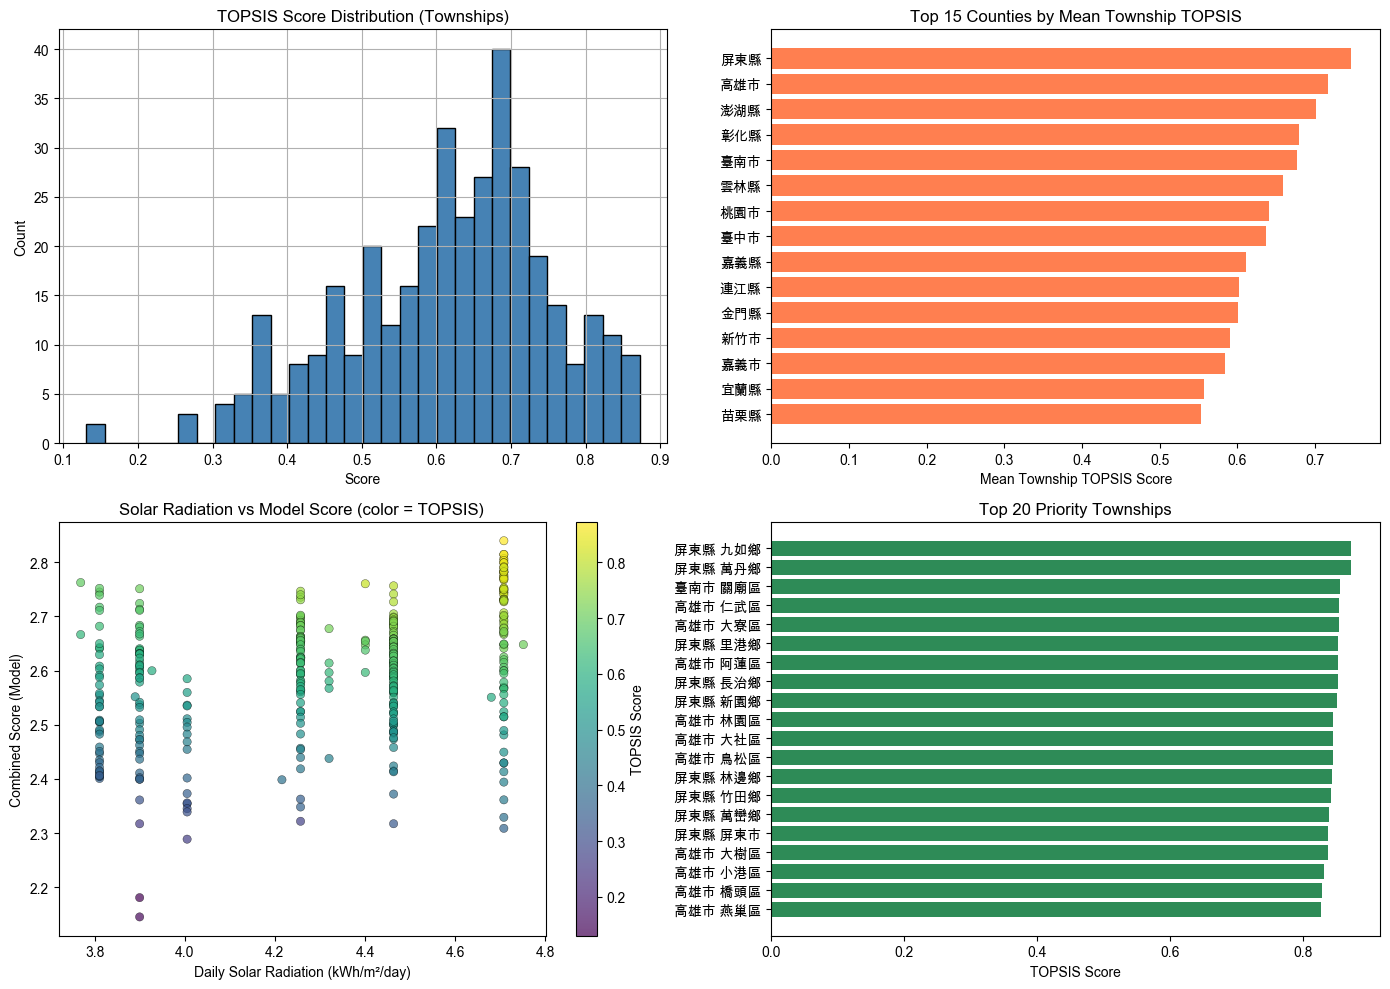

In [22]:
# ── 視覺化 ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

result['topsis_score'].hist(bins=30, ax=axes[0,0], edgecolor='k', color='steelblue')
axes[0,0].set_title('TOPSIS Score Distribution (Townships)')
axes[0,0].set_xlabel('Score')
axes[0,0].set_ylabel('Count')

top15_counties = county_rank.head(15)
axes[0,1].barh(top15_counties.index[::-1], top15_counties['topsis_mean'][::-1], color='coral')
axes[0,1].set_title('Top 15 Counties by Mean Township TOPSIS')
axes[0,1].set_xlabel('Mean Township TOPSIS Score')

sc = axes[1,0].scatter(
    result['daily_solar_radiation'],
    result['combined_score'],
    c=result['topsis_score'], cmap='viridis', alpha=0.7, edgecolors='k', linewidths=0.3
)
axes[1,0].set_xlabel('Daily Solar Radiation (kWh/m²/day)')
axes[1,0].set_ylabel('Combined Score (Model)')
axes[1,0].set_title('Solar Radiation vs Model Score (color = TOPSIS)')
plt.colorbar(sc, ax=axes[1,0], label='TOPSIS Score')

top20 = result.head(20).iloc[::-1]
labels = top20['COUNTYNAME'] + ' ' + top20['TOWNNAME']
axes[1,1].barh(labels, top20['topsis_score'], color='seagreen')
axes[1,1].set_title('Top 20 Priority Townships')
axes[1,1].set_xlabel('TOPSIS Score')

plt.tight_layout()
fig_path = ROOT / 'outputs/figures/transfer/05_mada_topsis_overview.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'Figure saved to {fig_path}')
plt.show()

---

## 解讀與注意事項

1. **TOPSIS Score 是相對排序工具**，不是絕對的裝置量預測值。
2. **本版鄉鎮 TOPSIS 不再直接納入縣級常數**（如 FIT、教育、就業），避免像前一版那樣把澎湖、金門這類整縣加成直接灌進每個鄉鎮名次。
3. **`avg_fit_rate`、`education_college_rate`、`employ_rate` 仍有價值**，但目前比較適合拿來做縣市背景解讀、政策討論或第二層決策，而不是第一層鄉鎮排序。
4. **若要做更完整的鄉鎮決策模型**，下一步應補進真正的鄉鎮級屋頂可用面積、建物型態、實際饋線容量或案場限制資料。
5. **外部驗證只是一個粗略 sanity check**：下面會把「平均鄉鎮分數」對「每鄉鎮平均裝置量」與「縣市總分」對「縣市總裝置量」分開看。

---

## 外部驗證：與實際裝置容量比較

以經濟部能源局「歷年各縣市太陽光電裝置容量」作為 ground truth，取最新完整年度 **114年**。

這裡拆成兩種對照：
1. **鄉鎮平均潛力**：`mean_topsis` / `mean_combined` 對 `capacity_per_town_kw`
2. **縣市總體規模**：`sum_topsis` / `sum_combined` 對 `actual_capacity_kw`

這樣比直接拿縣市平均分數去對縣市總容量更合理。

Matched counties: 22

County-level comparison:
COUNTYNAME  n_towns  mean_topsis  sum_topsis  mean_combined  sum_combined  best_rank  capacity_per_town_kw  actual_capacity_kw
       臺南市       37        0.677      25.038          2.626        97.154          3             79531.541             2942667
       彰化縣       26        0.680      17.668          2.634        68.491         49             82012.654             2132329
       雲林縣       20        0.659      13.182          2.607        52.143         66             83628.550             1672571
       高雄市       38        0.717      27.245          2.659       101.030          4             40070.605             1522683
       屏東縣       33        0.747      24.638          2.680        88.441          1             45771.333             1510454
       嘉義縣       18        0.611      10.999          2.566        46.187         75             64602.056             1162837
       臺中市       29        0.637      18.485          2.622     

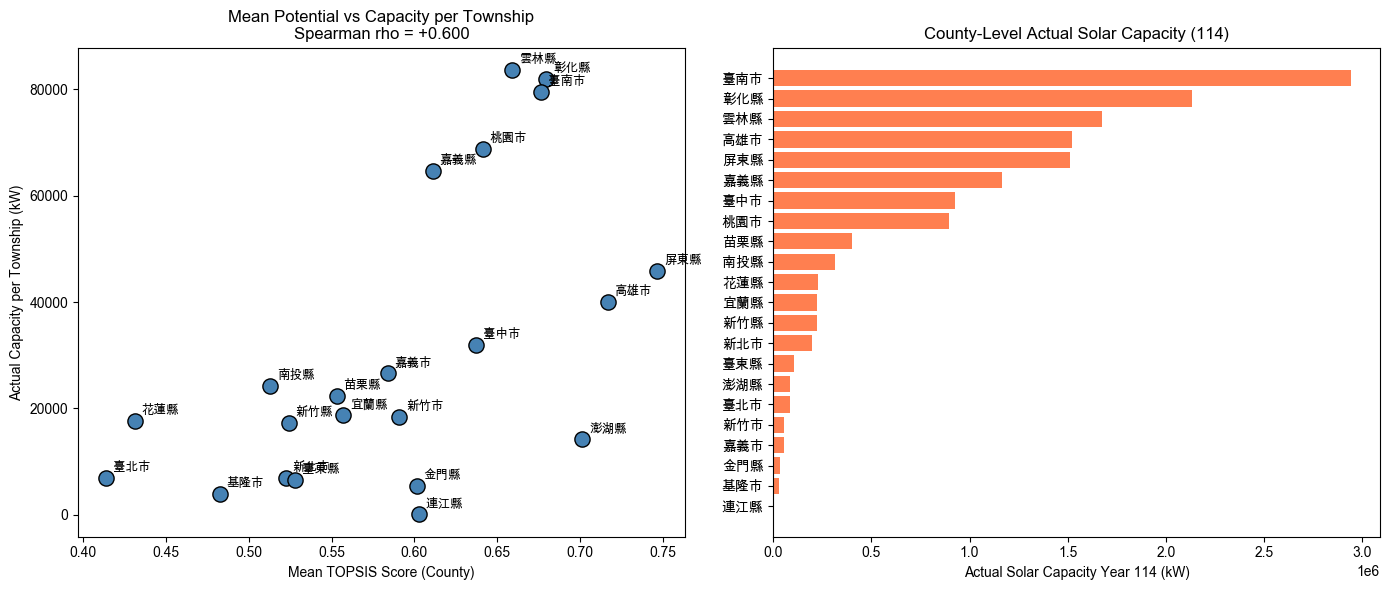

In [23]:
from scipy.stats import spearmanr

# ── 1. Load actual installation data (year 114) ────────────────────
actual_path = ROOT / 'data/taiwan/歷年各縣市太陽光電裝置容量(97-11502).csv'
actual = pd.read_csv(actual_path)

actual_114 = actual[actual['年別'] == 114].copy()
actual_114['縣市'] = actual_114['縣市'].str.replace('台', '臺', regex=False)
actual_114 = actual_114.rename(columns={'縣市': 'COUNTYNAME', '合計（瓩）': 'actual_capacity_kw'})

# ── 2. Aggregate township predictions to county-level ──────────────
county_pred = result.groupby('COUNTYNAME').agg(
    mean_topsis=('topsis_score', 'mean'),
    sum_topsis=('topsis_score', 'sum'),
    mean_combined=('combined_score', 'mean'),
    sum_combined=('combined_score', 'sum'),
    best_rank=('priority_rank', 'min'),
    n_towns=('TOWNCODE', 'count'),
).reset_index()

merged_val = county_pred.merge(
    actual_114[['COUNTYNAME', 'actual_capacity_kw']], on='COUNTYNAME', how='inner'
)
merged_val['capacity_per_town_kw'] = merged_val['actual_capacity_kw'] / merged_val['n_towns']

print(f'Matched counties: {len(merged_val)}')
print('\nCounty-level comparison:')
print(
    merged_val.sort_values('actual_capacity_kw', ascending=False)[[
        'COUNTYNAME', 'n_towns', 'mean_topsis', 'sum_topsis',
        'mean_combined', 'sum_combined', 'best_rank',
        'capacity_per_town_kw', 'actual_capacity_kw'
    ]].round(3).to_string(index=False)
)

checks = [
    ('mean_topsis', 'capacity_per_town_kw'),
    ('mean_combined', 'capacity_per_town_kw'),
    ('sum_topsis', 'actual_capacity_kw'),
    ('sum_combined', 'actual_capacity_kw'),
    ('best_rank', 'actual_capacity_kw'),
]

print('\nSpearman correlations:')
for score_col, target_col in checks:
    rho, pval = spearmanr(merged_val[score_col], merged_val[target_col])
    print(f'  {score_col:15s} vs {target_col:20s}: rho={rho:+.3f}, p={pval:.4f}')

# ── 3. Visualization ───────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

ax = axes[0]
ax.scatter(
    merged_val['mean_topsis'],
    merged_val['capacity_per_town_kw'],
    s=120, c='steelblue', edgecolors='k', zorder=3
)
for _, row in merged_val.iterrows():
    ax.annotate(
        row['COUNTYNAME'],
        (row['mean_topsis'], row['capacity_per_town_kw']),
        textcoords='offset points', xytext=(5, 5), fontsize=9, zorder=4
    )
rho_mean = spearmanr(merged_val['mean_topsis'], merged_val['capacity_per_town_kw'])[0]
ax.set_xlabel('Mean TOPSIS Score (County)')
ax.set_ylabel('Actual Capacity per Township (kW)')
ax.set_title(f'Mean Potential vs Capacity per Township\nSpearman rho = {rho_mean:+.3f}')

merged_sorted = merged_val.sort_values('actual_capacity_kw', ascending=True)
ax = axes[1]
ax.barh(merged_sorted['COUNTYNAME'], merged_sorted['actual_capacity_kw'], color='coral')
ax.set_xlabel('Actual Solar Capacity Year 114 (kW)')
ax.set_title('County-Level Actual Solar Capacity (114)')

plt.tight_layout()
fig_path = ROOT / 'outputs/figures/transfer/06_external_validation.png'
fig_path.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_path, dpi=300, bbox_inches='tight')
print(f'\nFigure saved to {fig_path}')
plt.show()

---
## 台灣地圖視覺化（Cartopy + IDW 插值）

以 Cartopy 畫台灣輪廓 + 逆距離權重插值（IDW）繪製鄉鎮層級熱力圖。
無需外部 shapefile，直接以 `centroid_lat/lon` 定位。

In [24]:
import sys
import matplotlib
matplotlib.use('module://matplotlib_inline.backend_inline')
from pathlib import Path
sys.path.insert(0, str(Path('..') / 'src'))
from taiwan_maps import load_merged_data, fig_topsis_heatmap, fig_multi_panel, fig_county_summary_bars, fig_top20_detail

df = load_merged_data('..')
print(f'Loaded {len(df)} townships with geo coords')

Loaded 368 townships with geo coords


In [25]:
# ── 圖 1：TOPSIS 綜合優先度熱力圖 ──────────────────────────────────
fig = fig_topsis_heatmap(
    df,
    out_path='../outputs/figures/transfer/map_01_topsis_heatmap.png',
    dpi=300
)

Saved: ../outputs/figures/transfer/map_01_topsis_heatmap.png


In [26]:
# ── 圖 2：四格對比（TOPSIS / 模型分數 / 日照 / 收入） ─────────────
fig = fig_multi_panel(
    df,
    out_path='../outputs/figures/transfer/map_02_four_panel.png',
    dpi=300
)

Saved: ../outputs/figures/transfer/map_02_four_panel.png


In [27]:
# ── 圖 3：縣市排名長條圖 ──────────────────────────────────────────
fig = fig_county_summary_bars(
    df,
    out_path='../outputs/figures/transfer/map_03_county_bars.png',
    dpi=300
)

Saved: ../outputs/figures/transfer/map_03_county_bars.png


In [28]:
# ── 圖 4：Top 20 深度分析（地圖 + 屬性比較 + 明細表格） ──────────
fig = fig_top20_detail(
    df,
    out_path='../outputs/figures/transfer/map_04_top20_detail.png',
    dpi=300
)

Saved: ../outputs/figures/transfer/map_04_top20_detail.png
